In [7]:
import pandas as pd
import tensorflow as tf
print(tf.__version__)
tsla = pd.read_csv("../data/processed/tsla.csv", index_col="Date", parse_dates=True)
tsla.head()

2.21.0


,Open,High,Low,Close,Adj Close,Volume,Daily Return,Rolling Volatility
Date,,,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000,NaN,NaN
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500,-0.042041,NaN
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500,0.005664,NaN
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000,-0.001562,NaN
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500,-0.001564,NaN


In [4]:
train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} rows)")
print(f"Test: {test.index.min()} to {test.index.max()} ({len(test)} rows)")

Train: 2015-01-02 00:00:00 to 2024-12-31 00:00:00 (2516 rows)
Test: 2025-01-02 00:00:00 to 2026-06-29 00:00:00 (372 rows)


In [5]:
import pmdarima as pm

model = pm.auto_arima(
    train["Adj Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,              # let it confirm d itself via its own stationarity test
    seasonal=False,      # no strong seasonal pattern expected in daily stock prices
    trace=True,          # prints each combination it tries
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True        # smart search instead of brute-force grid
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.41 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.157 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Fri, 03 Jul 2026   AIC                          16368.109
Time:                        10:37:53   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                  

c:\Users\acer\Downloads\10 Acadamy\projects\Week_9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\acer\Downloads\10 Acadamy\projects\Week_9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


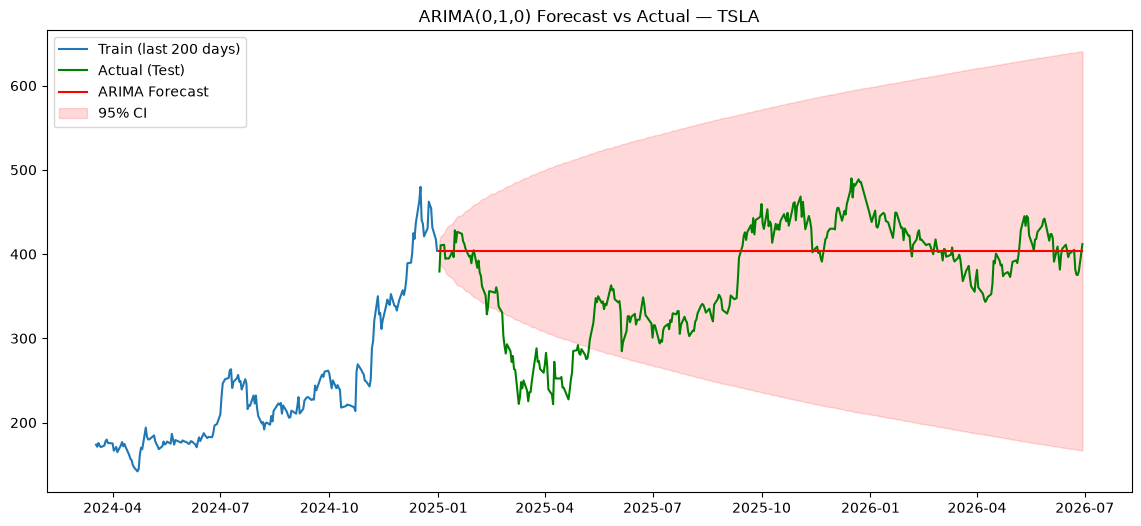

In [6]:
n_periods = len(test)
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(train.index[-200:], train["Adj Close"][-200:], label="Train (last 200 days)")
plt.plot(test.index, test["Adj Close"], label="Actual (Test)", color="green")
plt.plot(test.index, forecast, label="ARIMA Forecast", color="red")
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color="red", alpha=0.15, label="95% CI")
plt.legend()
plt.title("ARIMA(0,1,0) Forecast vs Actual — TSLA")
plt.show()

In [8]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Scale using ONLY train data stats — this matters, explained below
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[["Adj Close"]])
test_scaled = scaler.transform(test[["Adj Close"]])

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)

print(X_train.shape, y_train.shape)

(2456, 60) (2456,)


In [9]:
# Prepend last window_size days of train so first test prediction has full context
combined = np.concatenate([train_scaled[-window_size:], test_scaled])
X_test, y_test = create_sequences(combined, window_size)

print(X_test.shape, y_test.shape)

(372, 60) (372,)


In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape, X_test.shape)

(2456, 60, 1) (372, 60, 1)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mean_squared_error")
model_lstm.summary()

c:\Users\acer\Downloads\10 Acadamy\projects\Week_9\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 0.0062 - val_loss: 0.0028
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0016 - val_loss: 0.0062
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0014 - val_loss: 0.0046
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 9.8727e-04 - val_loss: 0.0016
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 9.9301e-04 - val_loss: 0.0015
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - l

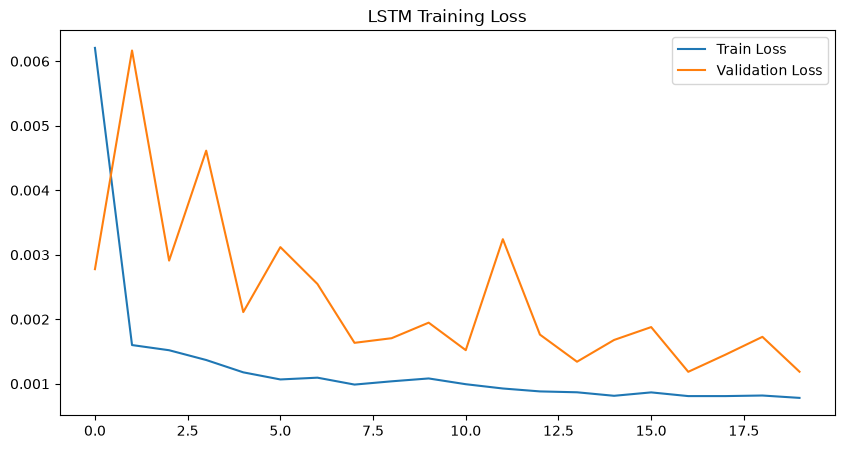

In [13]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("LSTM Training Loss")
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


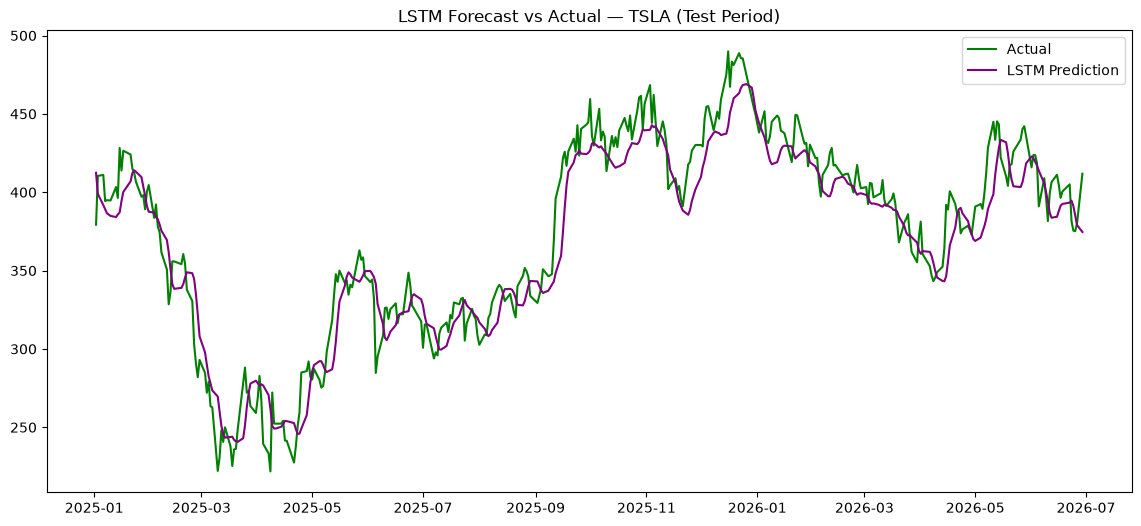

In [14]:
predictions_scaled = model_lstm.predict(X_test)

# Inverse transform back to actual price scale
predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14,6))
plt.plot(test.index, actual, label="Actual", color="green")
plt.plot(test.index, predictions, label="LSTM Prediction", color="purple")
plt.legend()
plt.title("LSTM Forecast vs Actual — TSLA (Test Period)")
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"\n{name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    return mae, rmse, mape

# ARIMA
arima_mae, arima_rmse, arima_mape = evaluate(test["Adj Close"].values, forecast, "ARIMA(0,1,0)")

# LSTM
lstm_mae, lstm_rmse, lstm_mape = evaluate(actual.flatten(), predictions.flatten(), "LSTM")


ARIMA(0,1,0)
MAE:  54.44
RMSE: 70.54
MAPE: 17.24%

LSTM
MAE:  14.32
RMSE: 18.10
MAPE: 3.96%


## Model Comparison Discussion

ARIMA(0,1,0) was selected by auto_arima as the best fit, essentially reducing to a 
random walk model with no exploitable AR or MA structure. This is consistent with 
the Efficient Market Hypothesis — it suggests TSLA's historical prices alone don't 
contain strong linear patterns that classical time series models can exploit.

LSTM outperformed ARIMA substantially on error metrics (MAPE 3.96% vs 17.24%), but 
this isn't a fully fair comparison: the LSTM evaluation used one-step-ahead 
predictions with real historical context refreshed daily, while ARIMA forecast the 
entire test period blind from a single starting point. This makes LSTM's task 
considerably easier in this setup.

A fairer test of long-horizon forecasting ability will come in Task 3, where LSTM 
will be evaluated using iterative/recursive forecasting — feeding its own 
predictions back in as input, the same handicap ARIMA faced here.